# Machine Learning II

#### Group Members:
- Afonso Fernandes / 20241710
- Lourenço Lima / 20241711
- Lucas Casimiro / 20241796

<a id="1."></a>    

## **1. Introduction**
This project was developed for the **Unsupervised Learning** course at NOVA IMS to address the challenge of understanding complex digital behaviors. The primary goal is to transition from simple data observation to an AI-assisted segmentation system for smartphone usage patterns.   

Our objective is to identify **Natural User Personas** within a dataset of 50,000 users. By applying unsupervised learning algorithms, specifically clustering and dimensionality reduction

    
<a id="2."></a>

## **2. Project Objectives**

<a id="2.1."></a>    

##### **1.1. Main goal:** - Develop an **AI-powered data application**  that segments users into meaningful clusters to help non-experts explore and visualize smartphone usage behaviors.   

<a id="2.2."></a>    

##### **1.2. Particular goals:** - **Advanced Exploratory Data Analysis (EDA)**: Perform deep-dive visualizations to understand feature distributions, detect outliers, and analyze correlations between usage time, stress levels, and productivity.
- **Unsupervised Learning Implementation**: Apply and compare at least two distinct algorithms, specifically **Clustering** (e.g., K-Means, DBSCAN) and **Dimensionality Reduction** (e.g., PCA, t-SNE).
- **Feature Engineering & Standardization**: Implement a robust preprocessing pipeline using **StandardScaler** to handle different variables (e.g., Daily Hours vs. App Counts) and ensure model integrity.
- **Cluster Interpretation & Validation**: Explain what the unsupervised learning is doing and interpret the resulting clusters to provide qualitative descriptions of user segments.
- **Interactive Prototype Development**: Build a functional application that runs live, demonstrating the results of the models in a way that is accessible to a non-technical audience.

# Exploratory Data Analysis

### Importing libraries and dataset

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler
import pickle

from functions import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We load the dataset (`wfh_burnout_dataset`) ,

In [53]:
df = pd.read_csv("wfh_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [54]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches',
       'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score',
       'burnout_score', 'burnout_risk'],
      dtype='object')

Key Features for Unsupervised Learning

    Behavioral Metrics (Auto-logged)

. work_hours (0.5-18h) - Daily work duration

. screen_time_hours (0-18h) - Active screen time

. meetings_count (0-20) - Virtual meetings per day

. app_switches (5-200) - Multitasking indicator

    Psychological/Recovery Metrics (Self-reported)

. sleep_hours (3-10h) - Sleep quality

. isolation_index (3-9) - UCLA Loneliness Scale

. breaks_taken (0-15) - Recovery behavior

. task_completion - Task completion rate

. after_hours_work - Whether work continues after hours

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB


It is possible to confirm that the dataset does not have any missing values, so we do not need to be worried with them.

### Separating Numeric and Categorical Columns for methods used later on in the notebook

In [56]:
num_cols = df.select_dtypes(include=[np.number]).drop('user_id', axis=1).columns.tolist()
cat_cols = df.select_dtypes(include=[object])
display(num_cols)
display(cat_cols)

['work_hours',
 'screen_time_hours',
 'meetings_count',
 'breaks_taken',
 'after_hours_work',
 'app_switches',
 'sleep_hours',
 'task_completion',
 'isolation_index',
 'fatigue_score',
 'burnout_score']

,day_type,burnout_risk
0,Weekday,Low
1,Weekday,Low
2,Weekend,Medium
3,Weekday,Medium
4,Weekend,Low
...,...,...
1995,Weekend,Low
1996,Weekend,Medium
1997,Weekend,Medium
1998,Weekday,Low


Using their data types, we divided the dataset's features into <u>numerical</u> and <u>categorical</u> groups.

In [57]:
display([df[num_cols].describe().T])


[                    count       mean        std    min      25%     50%  \
 work_hours         2000.0   8.955995   1.724214   4.73   7.7500   8.535   
 screen_time_hours  2000.0   7.689495   1.983181   2.91   6.2800   7.290   
 meetings_count     2000.0   3.728500   2.874877   0.00   2.0000   3.000   
 breaks_taken       2000.0   5.066000   1.762441   0.00   4.0000   5.000   
 after_hours_work   2000.0   0.156500   0.363420   0.00   0.0000   0.000   
 app_switches       2000.0  56.025500  23.702463   5.00  39.0000  52.000   
 sleep_hours        2000.0   6.894900   0.983893   3.58   6.3200   7.080   
 task_completion    2000.0  80.090670  12.708583  40.00  71.6725  80.900   
 isolation_index    2000.0   4.875500   1.656011   3.00   3.0000   5.000   
 fatigue_score      2000.0   6.560825   2.218042   1.45   4.7400   6.295   
 burnout_score      2000.0  35.656590  17.315039   6.06  21.0050  32.330   
 
                        75%     max  
 work_hours          9.9800   14.23  
 screen_ti

### Duplicates check

Checking for duplicate rows

In [58]:
check_duplicates(df)

Duplicate rows: 0


### Missing Values

Checking for missing values in the dataset

In [59]:
nan_counts = df.isnull().sum()
print(nan_counts)

user_id              0
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken         0
after_hours_work     0
app_switches         0
sleep_hours          0
task_completion      0
isolation_index      0
fatigue_score        0
burnout_score        0
burnout_risk         0
dtype: int64


## Feature Distributions 
In this section, we analyze the distribution of our behavioral features. Understanding the spread, skewness, and scale of our data is crucial for unsupervised learning because clustering algorithms like K-Means are highly sensitive to the scale of the variables and the presence of outliers.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB


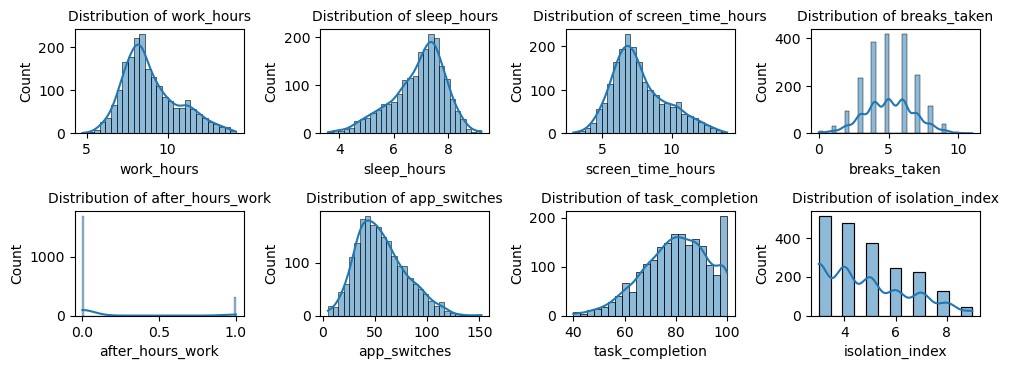

In [61]:
numerical_cols = [
    'work_hours',
    'sleep_hours',
    'screen_time_hours',
    'breaks_taken',
    'after_hours_work',
    'app_switches',
    'task_completion',
    'isolation_index',
]

# Call the function to generate the grid of plots
plot_distribution_grid(df, numerical_cols)

Note: We exclude fatigue_score and burnout_score from clustering as they are target/outcome variables. Our focus is on behavioral features (work_hours, screen_time, meetings, breaks, etc.)

### Numerical variables distribution

Checking for the numerical variables distribution in boxplots to identify potential outliers

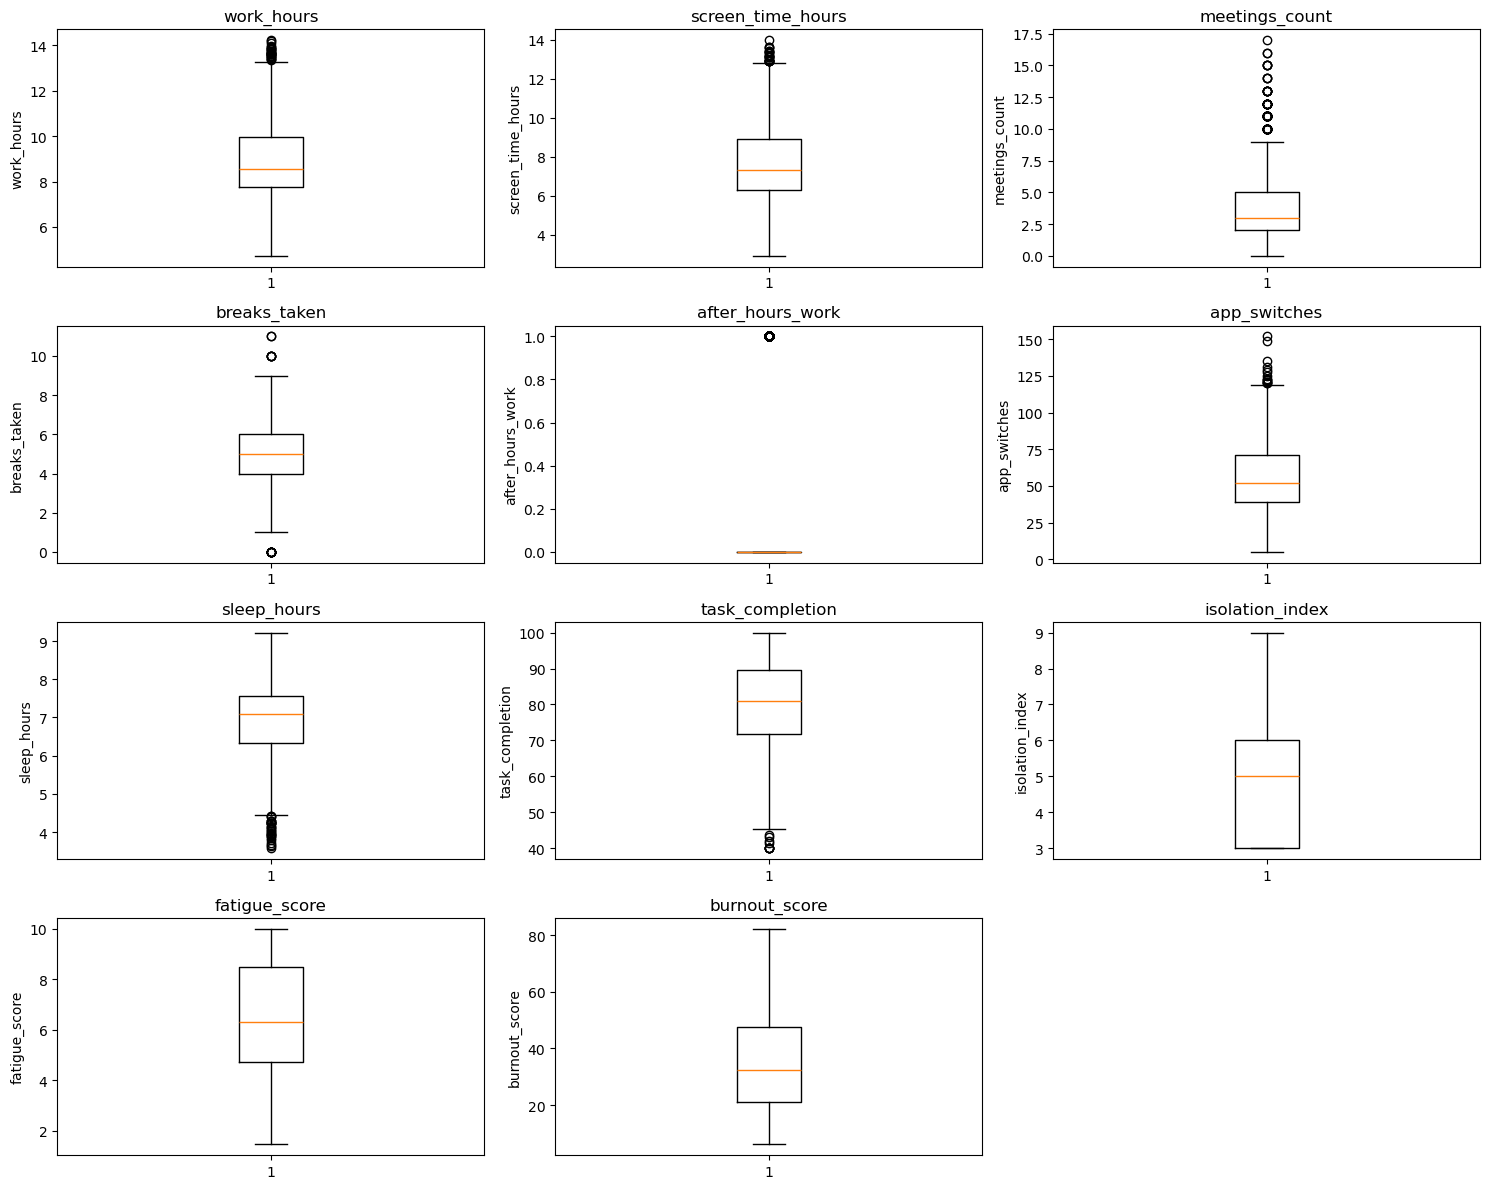

In [62]:
outlier_detection(df[num_cols])

As the column 'after_hours_work' only has 2 values, we'll create a bar chart to check for the distribution between 0 and 1 to verify if the information from said column isn't mostly constant (and later on encode this column if useful).

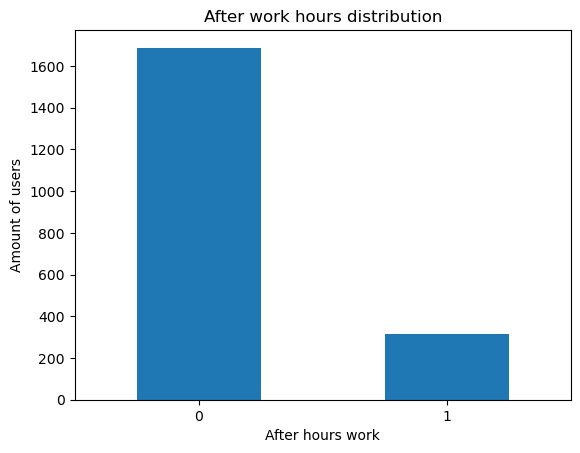

In [63]:
df['after_hours_work'].value_counts().sort_index().plot(kind='bar')
plt.title('After work hours distribution')
plt.xlabel('After hours work')
plt.ylabel('Amount of users')
plt.xticks(rotation=0)
plt.show()

### Categorical variables distributions

Using barcharts to check the categorical columns distributions

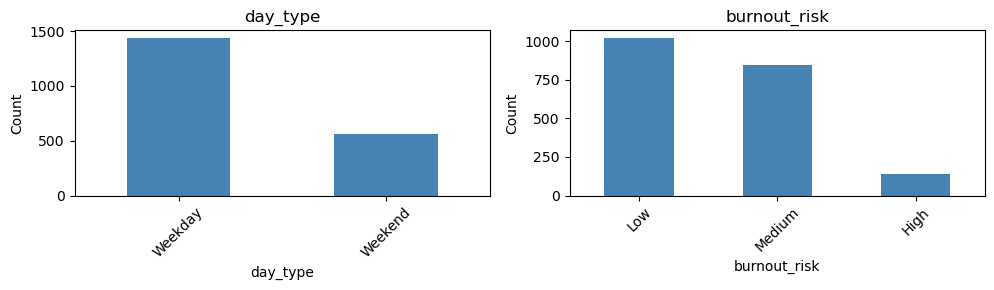

In [64]:
categorical_distributions(df)

### Correlations between variables

Creating a correlation heatmap to check for variables that are highly correlated


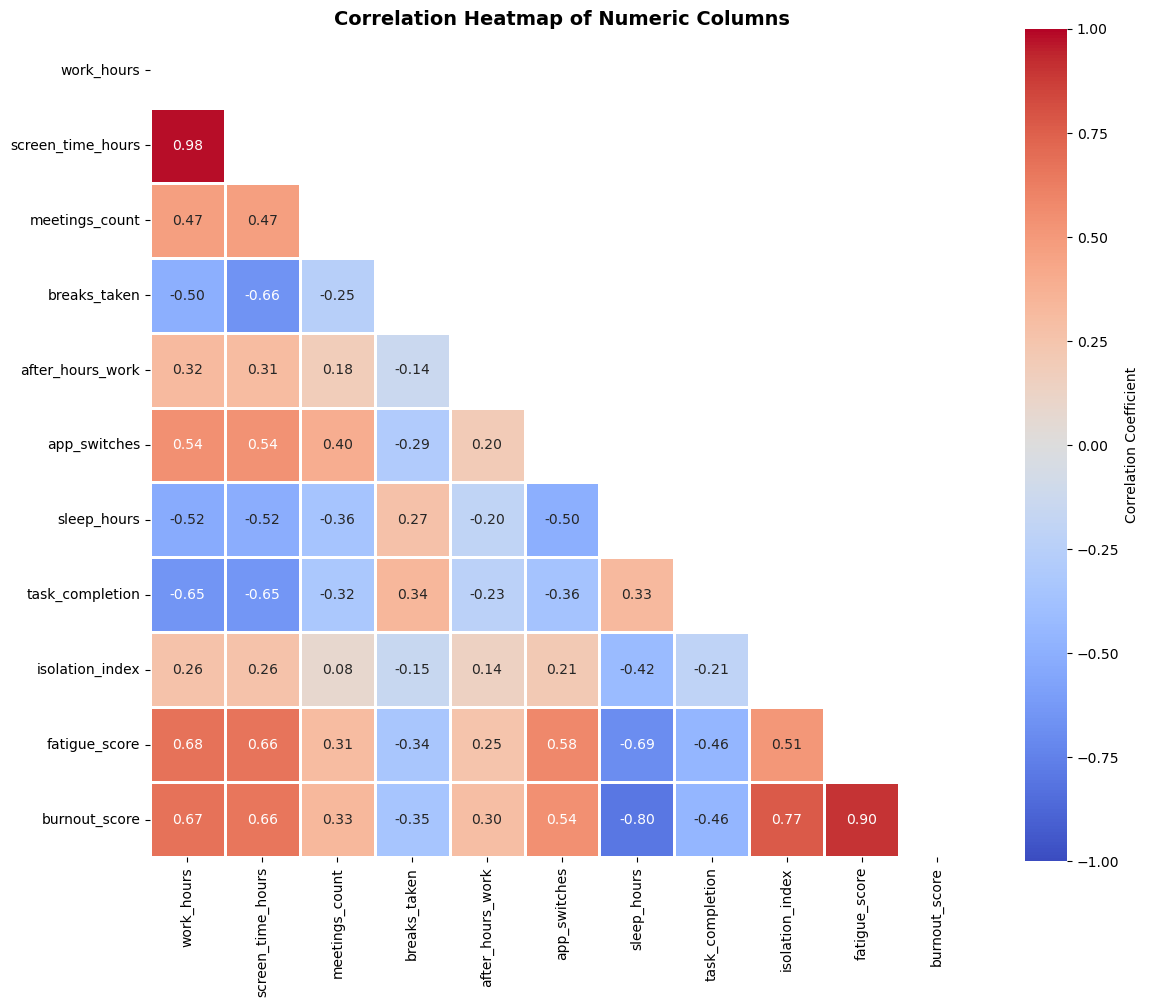

In [65]:
corr_heatmap(df, num_cols)

# Preprocessing

Most of the dataset is ready to use for unsupervised learning.

There are no missing values nor duplicates, and we have possible outliers in `meetings_count` (>10), `app_switches` (>120) and `sleep_hours` (<4). The decision is to keep these, as they represent distinct behavioral patterns. We will take them into consideration when choosing the scaler.

We do have high correlations between variables. The decision is to keep those with an absolute correlation value of under 0.90. We have one case to address:

 . `screen_time_hours` and `work_hours` have a correlation of 0.98. We will eliminate `screen_time_hours`, as `work_hours` is easier to interpret for clustering analysis.

For unsupervised learning, we exclude target variables (`fatigue_score`, `burnout_score`, `burnout_risk`) to ensure clusters are based purely on behavioral patterns rather than outcomes.

In [66]:
df.drop('screen_time_hours', axis=1, inplace=True)

Lastly, we need to scale our features, so they're ready to use for the algorithm, and no distances are calculated through disproportionate dimensions. We will use RobustScaler, due to the existence of outliers, which we decided to keep and deal with here.

In [67]:
# Features for unsupervised learning 
features_to_scale = ['work_hours', 'meetings_count', 
                     'breaks_taken', 'after_hours_work', 'app_switches', 
                     'sleep_hours', 'task_completion', 'isolation_index',
                     'fatigue_score', 'burnout_score']

X = df[features_to_scale]
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

We will store these features in pickle files to tranfer them to our next notebook.

In [68]:
# 3. Create a dictionary to keep everything organized
transfer_data = {
    'X_scaled': X_scaled,
    'feature_names': features_to_scale,
    'scaler': scaler,
    'original_df': df 
}

# 4. Save as a pickle file
with open('processed_data.pkl', 'wb') as f:
    pickle.dump(transfer_data, f)

print("Data and Scaler successfully pickled.")

Data and Scaler successfully pickled.
